In [1]:
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
class PlateWithHole(keras.Model):
    def __init__(self, network_u, network_v, network_w ,train_op, num_epoch, data_type):
        super().__init__()
        self.model_u = network_u
        self.model_v = network_v
        self.model_w = network_w
        
        # Call build on submodels
        self.model_u.build(input_shape=(None, 3))
        self.model_v.build(input_shape=(None, 3))
        self.model_w.build(input_shape=(None, 3))
        
        self.train_op = train_op
        self.num_epoch = num_epoch
        self.print_epoch = 100
        self.data_type = data_type       
        self.pi_ten = tf.constant([np.pi], dtype= 'float32')

    @tf.function
    def u(self, X):
        x=X[:,0:1]
        X1 = self.model_u(X)
        return X1*x
    
    @tf.function
    def v(self, X):
        y=X[:,1:2]
        X1 = self.model_v(X)   
        return X1*y

    @tf.function
    def w(self, X):
        z=X[:,2:3]
        X1 = self.model_w(X)   
        return X1*z
    
    @tf.function
    def call(self, X):
        uVal = self.u(X)
        vVal = self.v(X)
        wVal = self.w(X)
        disp = tf.concat([uVal, vVal , wVal], axis=1)
        return disp

    
    @tf.function
    def Diff(self,x,y,z):
        with tf.GradientTape(persistent=True) as g:
            g.watch(x)
            g.watch(y)
            g.watch(z)
            X=tf.concat( [x, y, z] ,axis=1)
            U = self.u(X)
            V = self.v(X)
            W = self.w(X)
        u_x = g.gradient(U, x)
        u_y = g.gradient(U, y)
        u_z = g.gradient(U, z)
        v_x = g.gradient(V, x)
        v_y = g.gradient(V, y)
        v_z = g.gradient(V, z)
        w_x = g.gradient(W, x)
        w_y = g.gradient(W, y)
        w_z = g.gradient(W, z)
        del g
    
        return u_x,u_y,u_z,v_x,v_y,v_z,w_x,w_y,w_z

    def strains(self,x,y,z):
        u_x,u_y,u_z,v_x,v_y,v_z,w_x,w_y,w_z=self.Diff(x,y,z)
        Ex= u_x
        Ey= v_y
        Ez= w_z
        strain_xy = (u_y + v_x )
        strain_yz = (w_y + v_z )
        strain_xz = (u_z + w_x )
    
        return  Ex,Ey,Ez,strain_xy,strain_yz,strain_xz

    def stresses(self,x,y,z):
        E = 10
        nu = 0.30
        Ex,Ey,Ez,strain_xy,strain_yz,strain_xz = self.strains(x,y,z)
        lam =(E*nu)/((1-2*nu)*(1+nu))
        mu  = E/(2*(1+nu))
        sigma_x = ((2*mu +lam)*Ex) + (lam *( Ey + Ez ))
        sigma_y = ((2*mu +lam)*Ey) + (lam *( Ex + Ez ))
        sigma_z = ((2*mu +lam)*Ez) + (lam *( Ex + Ey ))
        tau_xy = mu * strain_xy
        tau_yz = mu * strain_yz
        tau_xz = mu * strain_xz
        return sigma_x,sigma_y,sigma_z,tau_xy,tau_yz,tau_xz
    

    def equilibrium(self,x,y,z):
        E = 10
        nu = 0.30
        la =(E*nu)/((1-2*nu)*(1+nu))
        mu = E/(2*(1+nu))
        with tf.GradientTape(persistent=True) as g:
            g.watch(x)
            g.watch(y)
            g.watch(z)
            u_x,u_y,u_z,v_x,v_y,v_z,w_x,w_y,w_z=self.Diff(x,y,z)
        U_xx = g.gradient(u_x,x)
        V_xy =  g.gradient(v_y,x)
        W_xz =  g.gradient(w_z,x)
        U_yy =  g.gradient(u_y,y)
        U_zz = g.gradient(u_z, z)
        
        V_yy = g.gradient(v_y, y)
        U_xy = g.gradient(u_x, y)
        W_yz = g.gradient(w_z, y)
        V_xx = g.gradient(v_x,x)
        V_zz = g.gradient(v_z, z)

        W_zz = g.gradient(w_z, z)
        U_xz = g.gradient(u_x, z)
        V_yz = g.gradient(v_y, z)
        W_xx = g.gradient(w_x, x)
        W_yy = g.gradient(w_y, y)

        del  g
        residual_1 = (mu + la) * (U_xx + V_xy + W_xz) + ( mu * (U_xx + U_yy + U_zz))
        residual_2 = (mu + la) * (V_yy + U_xy + W_yz) + ( mu * (V_xx + V_yy + V_zz))
        residual_3 = (mu + la) * (W_zz + U_xz + V_yz) + ( mu * (W_xx + W_yy + W_zz))
               

        return  residual_1, residual_2 , residual_3

    @tf.function
    def loss_all(self, X_dom):

        x,y,z = X_dom[:,0:1] , X_dom[:,1:2] , X_dom[:,2:3] 
    
        # Stress boundary conditions
        Lx = 1  # Length in x-direction
        Ly = 1  # Length in y-direction
        Lz = 1  # Length in z-direction
        r = 0.5  # Hole radius
        E = 10
        ns_s= 31
        ns_u= 31
        ns_r= 31
        ns_1 = 31
        dx = 1./(ns_1-1)
        h = (dx*5)


        residual_1, residual_2 , residual_3 = self.equilibrium(x,y,z)
        loss_dom = ((h*(dx**3))/(E*E)) * tf.reduce_sum( tf.math.square(residual_1)+ tf.math.square(residual_2) + tf.math.square(residual_3))

        # right BC ( X=1 CONSTANT)
        y = np.linspace(0,Ly, ns_r).reshape(-1, 1).astype(np.float32)
        z = np.linspace(0,Lz, ns_r).reshape(-1, 1).astype(np.float32)
        Y, Z = np.meshgrid(y, z)
        points = np.stack((Y.flatten(), Z.flatten()), axis=1)
        X_r = Lx * np.ones((points.shape[0],1)).astype(np.float32)
        array1=np.hstack([X_r , points[:,0:1], points[:,1:2]])
        sigma_x_r,sigma_y_r,sigma_z_r,tau_xy_r,tau_yz_r,tau_xz_r = self.stresses(array1[:,0:1] ,array1[:,1:2] ,array1[:,2:3])
        loss_boundary_D1 = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square(sigma_x_r -0 )+tf.math.square(tau_xy_r-0)+tf.math.square(tau_xz_r-0))

        # TOP BC  ( Z=1 CONSTANT )
        y = np.linspace(0,Ly, ns_u).reshape(-1, 1).astype(np.float32)
        x = np.linspace(0,Lx, ns_u).reshape(-1, 1).astype(np.float32)
        X, Y = np.meshgrid(x, y)
        points = np.stack((X.flatten(), Y.flatten()), axis=1)
        Z_r = Lz * np.ones((points.shape[0],1)).astype(np.float32)
        array2=np.hstack([points[:,0:1],points[:,1:2] , Z_r ])
        sigma = 1* np.ones((points.shape[0],1)).astype(np.float32)
        sigma_x_u,sigma_y_u,sigma_z_u,tau_xy_u,tau_yz_u,tau_xz_u  = self.stresses(array2[:,0:1] ,array2[:,1:2] ,array2[:,2:3])
        loss_boundary_D2 = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square(tau_yz_u-0)+tf.math.square(sigma_z_u - sigma )+tf.math.square(tau_xz_u-0))


        # Surface outward BC(Y=1)
        z = np.linspace(0,Lz, ns_s).reshape(-1, 1).astype(np.float32)
        x = np.linspace(0,Lx, ns_s).reshape(-1, 1).astype(np.float32)
        X, Z = np.meshgrid(x, z)
        points = np.stack((X.flatten(), Z.flatten()), axis=1)
        Y_r = Ly * np.ones((points.shape[0],1)).astype(np.float32)
        array3=np.hstack([points[:,0:1], Y_r , points[:,1:2]])
        sigma_x_s,sigma_yy_s,sigma_z_s,tau_xy_s,tau_yz_s,tau_xz_s   = self.stresses(array3[:,0:1] ,array3[:,1:2] ,array3[:,2:3])
        loss_boundary_D3 = ((dx*dx)/(E*E))  * tf.reduce_sum(tf.math.square(tau_yz_s-0)+tf.math.square(sigma_yy_s-0)+tf.math.square(tau_xy_s-0))


        # Left BC ( X=0 CONSTANT)
        y = np.linspace(0,Ly, ns_r).reshape(-1, 1).astype(np.float32)
        z = np.linspace(0,Lz, ns_r).reshape(-1, 1).astype(np.float32)
        Y, Z = np.meshgrid(y, z)
        points = np.stack((Y.flatten(), Z.flatten()), axis=1)
        X_r = np.zeros((points.shape[0],1)).astype(np.float32)
        array4=np.hstack([X_r , points[:,0:1], points[:,1:2]])
        distances1 = np.sqrt(array4[:, 0]**2 + array4[:, 1]**2 + array4[:, 2]**2)
        array4 = array4[distances1 >= r]
        sigma_x_l,sigma_y_l,sigma_z_l,tau_xy_l,tau_yz_l , tau_xz_l = self.stresses(array4[:,0:1] ,array4[:,1:2] ,array4[:,2:3])
        loss_boundary_D4 = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square(tau_xy_l-0)+tf.math.square(tau_xz_l-0))


        # Bottom BC  ( Z = 0 CONSTANT )
        y = np.linspace(0,Ly, ns_u).reshape(-1, 1).astype(np.float32)
        x = np.linspace(0,Lx, ns_u).reshape(-1, 1).astype(np.float32)
        X, Y = np.meshgrid(x, y)
        points = np.stack((X.flatten(), Y.flatten()), axis=1)
        Z_r = np.zeros((points.shape[0],1)).astype(np.float32)
        array5=np.hstack([points[:,0:1] , points[:,1:2] , Z_r ])
        distances2 = np.sqrt(array5[:, 0]**2 + array5[:, 1]**2 + array5[:, 2]**2)
        array5 = array5[distances2 >= r]
        sigma_x_b,sigma_y_b,sigma_z_b,tau_xy_b,tau_yz_b,tau_xz_b  = self.stresses(array5[:,0:1] ,array5[:,1:2] ,array5[:,2:3])
        loss_boundary_D5 = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square(tau_yz_b-0)+tf.math.square(tau_xz_b-0))


        # Surface inside BC (Y=0)
        z = np.linspace(0,Lz, ns_s).reshape(-1, 1).astype(np.float32)
        x = np.linspace(0,Lx, ns_s).reshape(-1, 1).astype(np.float32)
        X, Z = np.meshgrid(x, z)
        points = np.stack((X.flatten(), Z.flatten()), axis=1)
        Y_r = np.zeros((points.shape[0],1)).astype(np.float32)
        array3=np.hstack([points[:,0:1], Y_r , points[:,1:2]])
        distances = np.sqrt(array3[:, 0]**2 + array3[:, 1]**2 + array3[:, 2]**2)
        array3 = array3[distances >= r]
        sigma_x_s1,sigma_yy_s1,sigma_z_s1,tau_xy_s1,tau_yz_s1,tau_xz_s1   = self.stresses(array3[:,0:1] ,array3[:,1:2] ,array3[:,2:3])
        loss_boundary_D6 = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square(tau_yz_s1-0)+tf.math.square(tau_xy_s1-0))


        # Arc BC
        # generate arc points
        ns_a1 = 31
        ns_a2 = 31
        xy_a = np.zeros((ns_a1 * ns_a2, 3)).astype(np.float32)
        theta = np.pi / ((ns_a1 - 1) * 2)
        fi = np.pi / ((ns_a2 - 1) * 2)

        for j in range(0, ns_a2):
            for i in range(0, ns_a1):
                xy_a[j * ns_a1 + i, 0] = np.cos(theta * i) * np.cos(fi * j) * r
                xy_a[j * ns_a1 + i, 1] = np.sin(theta * i) * np.cos(fi * j) * r
                xy_a[j * ns_a1 + i, 2] = np.sin(fi * j) * r

        tol = 1e-7

        xy_a[ns_a1-1, 0] = 0
        xy_a[-1, 0] = 0
        xy_a[-1, 1] = 0

        n_arc = (-1*xy_a) / r

        xarc= xy_a[:,0:1]
        yarc=xy_a[:,1:2]
        zarc=xy_a[:,2:3]

        nx_arc= n_arc[:,0:1]
        ny_arc=n_arc[:,1:2]
        nz_arc=n_arc[:,2:3]


        nx= tf.convert_to_tensor(nx_arc)
        ny=tf.convert_to_tensor(ny_arc)
        nz=tf.convert_to_tensor(nz_arc)


        sigma_xx_arc,sigma_yy_arc,sigma_zz_arc,tau_xy_arc,tau_yz_arc,tau_xz_arc  =  self.stresses(xarc,yarc,zarc)

        loss_boundary_D7 =  ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square((sigma_xx_arc*nx + tau_xy_arc*ny + tau_xz_arc*nz))+tf.math.square((tau_xy_arc*nx + sigma_yy_arc*ny + tau_yz_arc*nz)))
        loss_boundary_D8  = ((dx*dx)/(E*E)) * tf.reduce_sum(tf.math.square((tau_xz_arc* nx + tau_yz_arc* ny + sigma_zz_arc*nz)))

        loss_boundary_D =  loss_boundary_D1 + loss_boundary_D2 + loss_boundary_D3 + loss_boundary_D4 +\
                            loss_boundary_D7 + loss_boundary_D5 + loss_boundary_D6+loss_boundary_D8

        
        return  loss_boundary_D , loss_dom


    @tf.function
    def loss_grad(self, X_dom  ):
        with tf.GradientTape() as g:
            g.watch(self.trainable_variables)
            loss1,loss2 = self.loss_all(X_dom)
            losses = loss1+loss2
        grad = g.gradient(losses, self.trainable_variables)
        return loss1,loss2,losses, grad

    def train(self, X_dom):
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
        for epoch in range(self.num_epoch):
            with tf.GradientTape() as tape:
                loss_val1,loss_val2 = self.loss_all(X_dom)
                loss_val=loss_val1 + loss_val2
                grads = tape.gradient(loss_val, self.trainable_variables)
            optimizer.apply_gradients(zip(grads, self.trainable_variables))
            if (epoch + 1) % self.print_epoch == 0:
                print("Epoch:", epoch + 1, " Loss:", loss_val.numpy())



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


# Generate grid of points
Lx = 1  # Length in x-direction
Ly = 1  # Length in y-direction
Lz = 1  # Length in z-direction
r = 0.5  # Hole radius

ns_1 = 31
dx = 1./(ns_1-1)
h = (dx*5)

xy = np.zeros((ns_1*ns_1*ns_1, 3)).astype(np.float32)
k = 0
for i in range(0,ns_1):
    for j in range(0,ns_1):
        for m in range(0,ns_1):
            xy[k, 0] = i * dx
            xy[k, 1] = j * dx
            xy[k, 2] = m * dx
            k = k+1

points = xy

# Filter out points inside the hole
distances = np.sqrt(points[:, 0]**2 + points[:, 1]**2 + points[:, 2]**2)
valid_points = points[distances >= r]

ns_a1 = 31
ns_a2 = 31
xy_a = np.zeros((ns_a1 * ns_a2, 3)).astype(np.float32)
theta = np.pi / ((ns_a1 - 1) * 2)
fi = np.pi / ((ns_a2 - 1) * 2)


for j in range(0, ns_a2):
    for i in range(0, ns_a1):
        xy_a[j * ns_a1 + i, 0] = np.cos(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 1] = np.sin(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 2] = np.sin(fi * j) * r


In [4]:
# x_domain = np.vstack([valid_points,xy_a])

# array3 = x_domain


# # Create a figure and add a 3D axis
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# # Plot the outline of the quarter-sphere using lines
# ax.scatter(array3[:, 0], array3[:, 1], array3[:, 2], c='b', linestyle='-', linewidth=1)



# ax.set_xlabel('X Label')
# ax.set_ylabel('Y Label')
# ax.set_zlabel('Z Label')
# ax.set_title('Outline of Cube')

# # plt.show()
# valid_points.shape

In [5]:
x_domain = np.vstack([valid_points,xy_a])
y_domain = np.zeros_like(x_domain)

In [6]:
data_type = 'float32'
## domain points
X_dom_tf = tf.convert_to_tensor(x_domain,dtype=tf.float32)
Y_dom_tf = tf.convert_to_tensor(y_domain,dtype=tf.float32)

tf.keras.backend.set_floatx(data_type)

# Create the network models for u and v separately
network_u = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

network_v = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

network_w = keras.Sequential([
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(20, activation='tanh'),
    keras.layers.Dense(1)
])

train_op = tf.keras.optimizers.Adam(learning_rate=0.005)
num_epoch = 100
pred_model = PlateWithHole( network_u , network_v ,network_w, train_op , num_epoch , data_type)



In [7]:
# pred_model.train(X_dom_tf)
# pred_model.get_weights()

In [8]:
import scipy.optimize
import numpy as np 
import tensorflow as tf

class Opt_lbfgsb:

    def __init__(self, pinn, X_dom,factr=10, pgtol=1e-10, m=50, maxls=50, maxiter=8000):
        # set options
        self.pinn = pinn   
        self.X_dom=X_dom

        self.factr = factr
        self.pgtol = pgtol
        self.m = m
        self.maxls = maxls
        self.maxiter = maxiter
        self.metrics = ['loss']
        self.his_iter = []
        self.his_loss = []

    def set_weights(self, flat_weights):
        # get model weights
        shapes = [ w.shape for w in self.pinn.get_weights() ]
        # compute splitting indices
        split_ids = np.cumsum([ np.prod(shape) for shape in [0] + shapes ])
        # reshape weights
        weights = [ flat_weights[from_id:to_id].reshape(shape)
            for from_id, to_id, shape in zip(split_ids[:-1], split_ids[1:], shapes) ]
        # set weights to the model
        self.pinn.set_weights(weights)

    @tf.function
    def Loss_grad(self):
        with tf.GradientTape() as g:
            l1,l2,loss, grad = self.pinn.loss_grad(self.X_dom)
        grads = g.gradient(loss, self.pinn.trainable_variables)      
        return loss, grads, l1, l2


    def Loss(self, weights):
        # update weights
        self.set_weights(weights)
        self.iteration_counter += 1
        l1,l2,loss, grads = self.pinn.loss_grad(self.X_dom)
        # convert tf.Tensor to flatten ndarray
        
        print('Iteration:', self.iteration_counter, 'Loss =',loss.numpy(), '')
        self.his_iter.append(self.iteration_counter) 
        self.his_loss.append(loss)
        loss = loss.numpy().astype('float64')
        grads = np.concatenate([ g.numpy().flatten() for g in grads ]).astype('float64')

        return loss, grads

    def fit(self):
        # get initial weights as a flat vector
        initial_weights = np.concatenate([ w.flatten() for w in self.pinn.get_weights() ])
        # optimize the weight vector
        print('Optimizer: L-BFGS-B (Provided by Scipy package)')
        print('Initializing the framework ...')
        
        self.iteration_counter = 0  # Initialize the iteration counter

        result = scipy.optimize.fmin_l_bfgs_b(func=self.Loss, x0=initial_weights,factr=self.factr, pgtol=self.pgtol, m=self.m, maxls=self.maxls, maxiter=self.maxiter)
        
        return result,[np.array(self.his_iter), np.array(self.his_loss)]

In [125]:
l_bfgs_b = Opt_lbfgsb(pred_model, X_dom_tf )
result,history = l_bfgs_b.fit()

Optimizer: L-BFGS-B (Provided by Scipy package)
Initializing the framework ...
Iteration: 1 Loss = 3.3803648e-05 
Iteration: 2 Loss = 37.755573 
Iteration: 3 Loss = 3.380276e-05 
Iteration: 4 Loss = 3.3802004e-05 
Iteration: 5 Loss = 3.3801094e-05 
Iteration: 6 Loss = 3.3800112e-05 
Iteration: 7 Loss = 3.3798562e-05 
Iteration: 8 Loss = 3.3795062e-05 
Iteration: 9 Loss = 3.3798347e-05 
Iteration: 10 Loss = 3.3793873e-05 
Iteration: 11 Loss = 3.379146e-05 
Iteration: 12 Loss = 3.3789736e-05 
Iteration: 13 Loss = 3.3787772e-05 
Iteration: 14 Loss = 3.3784887e-05 
Iteration: 15 Loss = 3.3782926e-05 
Iteration: 16 Loss = 3.378105e-05 
Iteration: 17 Loss = 3.377984e-05 
Iteration: 18 Loss = 3.377843e-05 
Iteration: 19 Loss = 3.3775366e-05 
Iteration: 20 Loss = 3.3770622e-05 
Iteration: 21 Loss = 3.3766013e-05 
Iteration: 22 Loss = 3.3762648e-05 
Iteration: 23 Loss = 3.375806e-05 
Iteration: 24 Loss = 3.3753346e-05 
Iteration: 25 Loss = 3.3745688e-05 
Iteration: 26 Loss = 3.3740045e-05 
Iter

KeyboardInterrupt: 

In [69]:
L = result
# it = result[2]

NameError: name 'result' is not defined

In [70]:
# x_test_c = 0*np.ones((21,1),dtype="float32")

x_test_c = np.linspace(0.2, 1, 21, dtype= 'float32').reshape(-1,1)
y_test_v =  0*np.ones((21,1),dtype="float32")
# y_test_v = np.linspace(0.2, 1, 21, dtype= 'float32').reshape(-1,1)


# x1_test=np.hstack([x_test_c,y_test_v])
x1,x2,x3 =pred_model.stresses( x_test_c,y_test_v )
# ytest =pred_model(x1_test)

# x1_test
# ytest
np.hstack([x1,x2,x3])


TypeError: PlateWithHole.stresses() missing 1 required positional argument: 'z'

In [126]:

# Generate grid of points
Lx = 1  # Length in x-direction
Ly = 1  # Length in y-direction
Lz = 1  # Length in z-direction
r = 0.5  # Hole radius

ns_1 = 51
dx = 1./(ns_1-1)
h = (dx*5)

xy = np.zeros((ns_1*ns_1*ns_1, 3)).astype(np.float32)
k = 0
for i in range(0,ns_1):
    for j in range(0,ns_1):
        for m in range(0,ns_1):
            xy[k, 0] = i * dx
            xy[k, 1] = j * dx
            xy[k, 2] = m * dx
            k = k+1

points = xy

# Filter out points inside the hole
distances = np.sqrt(points[:, 0]**2 + points[:, 1]**2 + points[:, 2]**2)
valid_points = points[distances >= r]

ns_a1 = 51
ns_a2 = 51
xy_a = np.zeros((ns_a1 * ns_a2, 3)).astype(np.float32)
theta = np.pi / ((ns_a1 - 1) * 2)
fi = np.pi / ((ns_a2 - 1) * 2)


for j in range(0, ns_a2):
    for i in range(0, ns_a1):
        xy_a[j * ns_a1 + i, 0] = np.cos(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 1] = np.sin(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 2] = np.sin(fi * j) * r
x_domain=np.vstack([valid_points,xy_a])

X=x_domain[:,0:1]
Y=x_domain[:,1:2]
Z=x_domain[:,2:3]

sigma_x_pred,sigma_y_pred,sigma_z_pred,tau_xy_pred,tau_yz_pred,tau_xz_pred= pred_model.stresses(X,Y,Z)
predicted_displacement =pred_model(x_domain)
x_disp = predicted_displacement[:,0:1]
y_disp = predicted_displacement[:,1:2]
z_disp= predicted_displacement[:,2:3]

variation of sigma-x


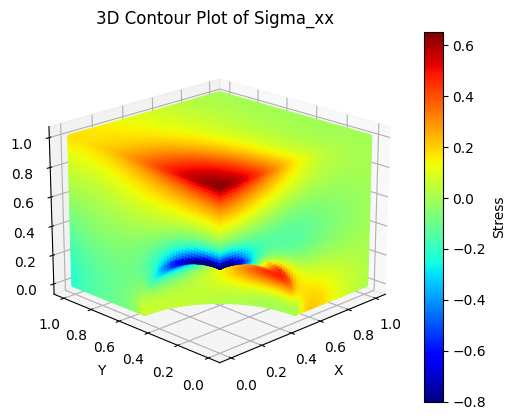

In [133]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Rotate the plot by 90 degrees by changing the azimuth angle.
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)

ax.scatter(X, Y, Z, c=sigma_x_pred, cmap='jet',vmax=0.7,vmin=-0.8)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of Sigma_xx')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=sigma_x_pred, cmap='jet',vmax=0.65,vmin=-0.8))
cbar.set_label('Stress')

plt.show()
# This code will create a 3D scatter plot where the color of each point represents the stress value. You can customize the colormap and other plot settings to suit your needs.



variation of sigma-y


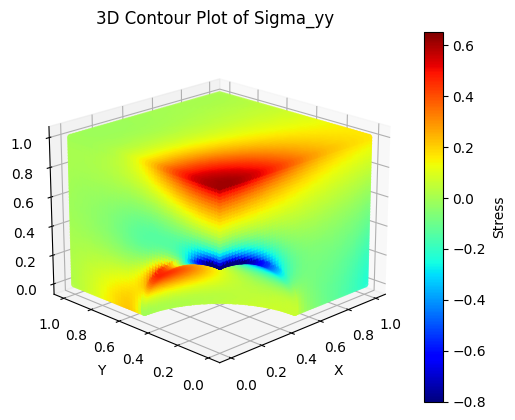

In [134]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)
ax.scatter(X, Y, Z, c=sigma_y_pred, cmap='jet',vmax=0.6,vmin=-0.8)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of Sigma_yy')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=sigma_y_pred, cmap='jet',vmax=0.65,vmin=-0.8))
cbar.set_label('Stress')

plt.show()
# This code will create a 3D scatter plot where the color of each point represents the stress value. You can customize the colormap and other plot settings to suit your needs.


Variation of Sigma_zz

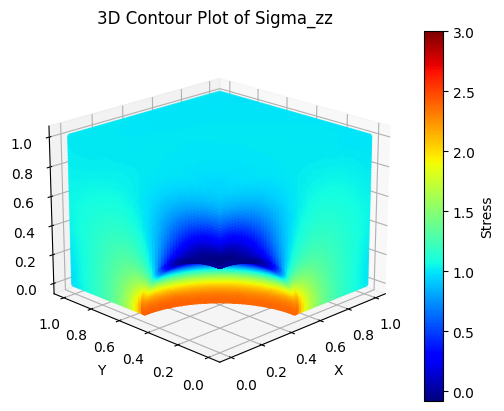

In [130]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)
ax.scatter(X, Y, Z, c=sigma_z_pred, cmap='jet',vmax=3)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of Sigma_zz')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=sigma_z_pred, cmap='jet',vmax=3))
cbar.set_label('Stress')

plt.show()

# This code will create a 3D scatter plot where the color of each point represents the stress value. You can customize the colormap and other plot settings to suit your needs.


variation of x displacement

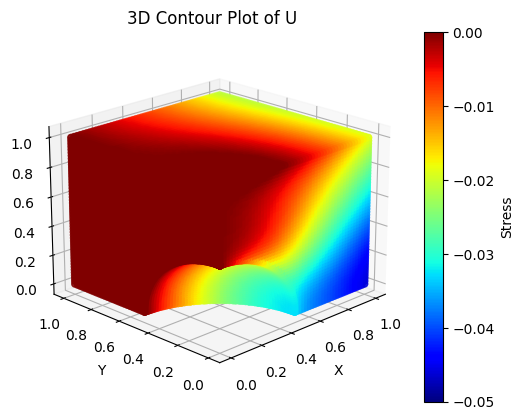

In [135]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)
ax.scatter(X, Y, Z, c=x_disp, cmap='jet',vmax=0,vmin=-0.05)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of U ')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=x_disp, cmap='jet',vmax=0,vmin=-0.05))
cbar.set_label('Stress')

plt.show()


variation of V

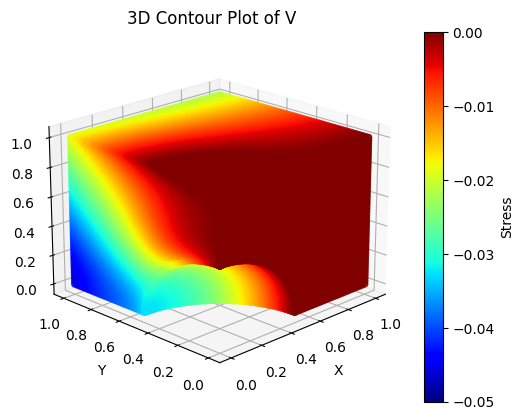

In [139]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)
ax.scatter(X, Y, Z, c=y_disp, cmap='jet',vmax=0,vmin=-0.05)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of V ')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=y_disp, cmap='jet',vmax=0,vmin=-0.05))
cbar.set_label('Stress')

plt.show()


Variation of W


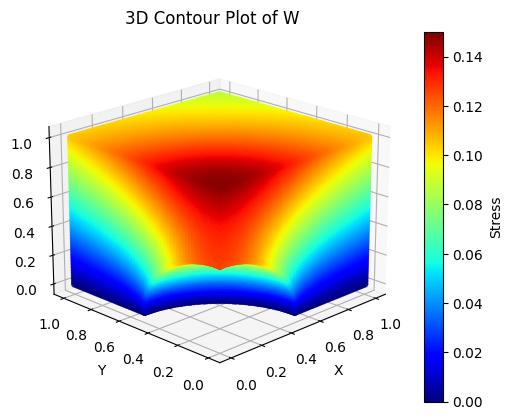

In [138]:
# Create a 3D scatter plot to visualize the points.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
elevation_angle = 20  # Adjust this angle to change the elevation.
azimuth_angle = -135  # Adjust this angle to change the azimuth.

ax.view_init(elevation_angle, azimuth_angle)
ax.scatter(X, Y, Z, c=z_disp, cmap='jet',vmin=0,vmax=0.15)  # You can choose a different colormap.

# Add labels and title.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Contour Plot of W ')

# Create a colorbar to indicate stress levels.
cbar = plt.colorbar(ax.scatter(X, Y, Z, c=z_disp, cmap='jet',vmin=0,vmax=0.15))
cbar.set_label('Stress')

plt.show()



<!-- Analytical solution -->

In [34]:
ns_u=100 
# TOP BC  ( Z CONSTANT )
Lx=1
Ly=1
r1=0.5

y = np.linspace(0,Ly, ns_u).reshape(-1, 1).astype(np.float32)
x = np.linspace(0,Lx, ns_u).reshape(-1, 1).astype(np.float32)
X, Y = np.meshgrid(x, y)
points = np.stack((X.flatten(), Y.flatten()), axis=1)
Z_r = 0* np.ones((points.shape[0],1)).astype(np.float32)
array2=np.hstack( [points[:,0:1] , points[:,1:2] , Z_r])

distances = np.sqrt(points[:, 0]**2 + points[:, 1]**2)
valid_points = array2[distances >= r1]
x1,y1 = valid_points[:,0:1], valid_points[:,1:2]
r=(x1**2+y1**2)**0.5



In [35]:
nu=0.3
a=0.5
sigma_0=1
term1= (4-5*nu)/(2*(7-5*nu)) * ((a/r)**3)
term2= (9)/(2*(7-5*nu)) * ((a/r)**5)
sigma_zz = sigma_0*(1+term1+term2)

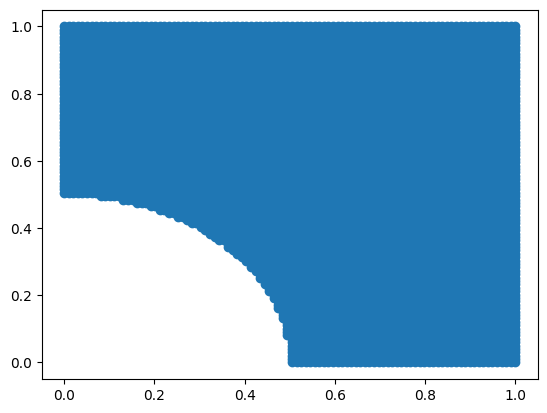

In [36]:
plt.scatter(x1,y1)

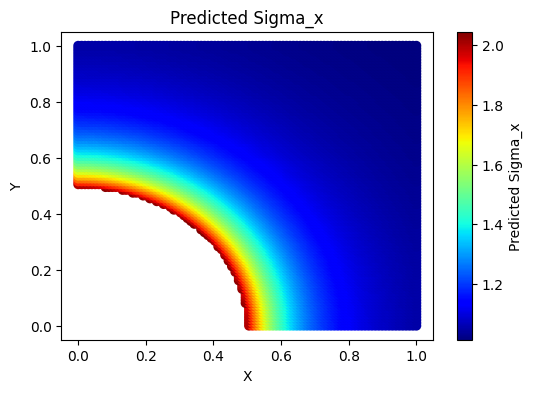

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # Set the figure size

# Plot the scatter points with MATLAB-like style
scatter = plt.scatter(valid_points[:,0:1], valid_points[:,1:2], c=sigma_zz, cmap='jet', s=50, edgecolors='k', linewidths=0.005)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Predicted Sigma_x')

# Set axis labels and title
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Predicted Sigma_x')

# Add grid lines
# plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [38]:
# Stress boundary conditions
Lx = 1  # Length in x-direction
Ly = 1  # Length in y-direction
Lz = 1  # Length in z-direction
r = 0.5  # Hole radius

ns_s=21
ns_u=21
ns_r=21
    

# Left BC ( X=0 CONSTANT)
y = np.linspace(0,Ly, ns_r).reshape(-1, 1).astype(np.float32)
z = np.linspace(0,Lz, ns_r).reshape(-1, 1).astype(np.float32)
Y, Z = np.meshgrid(y, z)
points = np.stack((Y.flatten(), Z.flatten()), axis=1)
X_r = np.zeros((points.shape[0],1)).astype(np.float32)
array4=np.hstack([X_r , points[:,0:1], points[:,1:2]])
distances1 = np.sqrt(array4[:, 0]**2 + array4[:, 1]**2 + array4[:, 2]**2)
array4 = array4[distances1 >= r]



# Bottom BC  ( Z = 0 CONSTANT )
y = np.linspace(0,Ly, ns_u).reshape(-1, 1).astype(np.float32)
x = np.linspace(0,Lx, ns_u).reshape(-1, 1).astype(np.float32)
X, Y = np.meshgrid(x, y)
points = np.stack((X.flatten(), Y.flatten()), axis=1)
Z_r = np.zeros((points.shape[0],1)).astype(np.float32)
array5=np.hstack([points[:,0:1] , points[:,1:2] , Z_r ])
distances2 = np.sqrt(array5[:, 0]**2 + array5[:, 1]**2 + array5[:, 2]**2)
array5 = array5[distances2 >= r]



# Surface inside BC (Y=0)
z = np.linspace(0,Lz, ns_s).reshape(-1, 1).astype(np.float32)
x = np.linspace(0,Lx, ns_s).reshape(-1, 1).astype(np.float32)
X, Z = np.meshgrid(x, z)
points = np.stack((X.flatten(), Z.flatten()), axis=1)
Y_r = np.zeros((points.shape[0],1)).astype(np.float32)
array3=np.hstack([points[:,0:1], Y_r , points[:,1:2]])
distances = np.sqrt(array3[:, 0]**2 + array3[:, 1]**2 + array3[:, 2]**2)
array3 = array3[distances >= r]


In [39]:
for i in array3:
    print(i)

[0.5 0.  0. ]
[0.55 0.   0.  ]
[0.6 0.  0. ]
[0.65 0.   0.  ]
[0.7 0.  0. ]
[0.75 0.   0.  ]
[0.8 0.  0. ]
[0.85 0.   0.  ]
[0.9 0.  0. ]
[0.95 0.   0.  ]
[1. 0. 0.]
[0.5  0.   0.05]
[0.55 0.   0.05]
[0.6  0.   0.05]
[0.65 0.   0.05]
[0.7  0.   0.05]
[0.75 0.   0.05]
[0.8  0.   0.05]
[0.85 0.   0.05]
[0.9  0.   0.05]
[0.95 0.   0.05]
[1.   0.   0.05]
[0.5 0.  0.1]
[0.55 0.   0.1 ]
[0.6 0.  0.1]
[0.65 0.   0.1 ]
[0.7 0.  0.1]
[0.75 0.   0.1 ]
[0.8 0.  0.1]
[0.85 0.   0.1 ]
[0.9 0.  0.1]
[0.95 0.   0.1 ]
[1.  0.  0.1]
[0.5  0.   0.15]
[0.55 0.   0.15]
[0.6  0.   0.15]
[0.65 0.   0.15]
[0.7  0.   0.15]
[0.75 0.   0.15]
[0.8  0.   0.15]
[0.85 0.   0.15]
[0.9  0.   0.15]
[0.95 0.   0.15]
[1.   0.   0.15]
[0.5 0.  0.2]
[0.55 0.   0.2 ]
[0.6 0.  0.2]
[0.65 0.   0.2 ]
[0.7 0.  0.2]
[0.75 0.   0.2 ]
[0.8 0.  0.2]
[0.85 0.   0.2 ]
[0.9 0.  0.2]
[0.95 0.   0.2 ]
[1.  0.  0.2]
[0.45 0.   0.25]
[0.5  0.   0.25]
[0.55 0.   0.25]
[0.6  0.   0.25]
[0.65 0.   0.25]
[0.7  0.   0.25]
[0.75 0.   0.25]
[0.

In [17]:
# Arc BC
# generate arc points
ns_a1 = 21
ns_a2 = 21
xy_a = np.zeros((ns_a1 * ns_a2, 3)).astype(np.float32)
theta = np.pi / ((ns_a1 - 1) * 2)
fi = np.pi / ((ns_a2 - 1) * 2)

for j in range(0, ns_a2):
    for i in range(0, ns_a1):
        xy_a[j * ns_a1 + i, 0] = np.cos(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 1] = np.sin(theta * i) * np.cos(fi * j) * r
        xy_a[j * ns_a1 + i, 2] = np.sin(fi * j) * r

tol = 1e-7

# # Thresholding operation to set values very close to zero to exactly zero
# for i in range(xy_a.shape[0]):
#     for j in range(xy_a.shape[1]):
#         if abs(xy_a[i, j]) < tol:
#             xy_a[i, j] = 0.0

xy_a[20, 0] = 0
xy_a[-1, 0] = 0
xy_a[-1, 1] = 0


n_arc = (-1*xy_a) / r



xarc= xy_a[:,0:1]
yarc=xy_a[:,1:2]
zarc=xy_a[:,2:3]

nx_arc= n_arc[:,0:1]
ny_arc=n_arc[:,1:2]
nz_arc=n_arc[:,2:3]


nx= tf.convert_to_tensor(nx_arc)
ny=tf.convert_to_tensor(ny_arc)
nz=tf.convert_to_tensor(nz_arc)



In [18]:
for i in xy_a:
    print(i)

[0.5 0.  0. ]
[0.49845865 0.03922955 0.        ]
[0.49384418 0.07821723 0.        ]
[0.48618495 0.11672268 0.        ]
[0.47552827 0.1545085  0.        ]
[0.46193975 0.19134171 0.        ]
[0.44550326 0.22699524 0.        ]
[0.42632008 0.26124927 0.        ]
[0.4045085  0.29389262 0.        ]
[0.38020298 0.32472402 0.        ]
[0.35355338 0.35355338 0.        ]
[0.32472402 0.38020298 0.        ]
[0.29389262 0.4045085  0.        ]
[0.26124927 0.42632008 0.        ]
[0.22699524 0.44550326 0.        ]
[0.19134171 0.46193975 0.        ]
[0.1545085  0.47552827 0.        ]
[0.11672268 0.48618495 0.        ]
[0.07821723 0.49384418 0.        ]
[0.03922955 0.49845865 0.        ]
[0.  0.5 0. ]
[0.49845865 0.         0.03922955]
[0.49692208 0.03910862 0.03922955]
[0.49232182 0.07797612 0.03922955]
[0.48468623 0.11636286 0.03922955]
[0.47406235 0.1540322  0.03922955]
[0.46051577 0.19075188 0.03922955]
[0.4441299  0.2262955  0.03922955]
[0.42500588 0.26044393 0.03922955]
[0.40326154 0.29298666 0.03